# 🎫 AI-Powered Support Ticket Classification System
## Task 2 - Machine Learning Project
### Objective
The objective of this project is to automatically classify customer support tickets into appropriate categories and predict their priority levels using Natural Language Processing (NLP) and Machine Learning techniques.

# Step 1: Import Required Libraries

In this step, we import all necessary Python libraries required for:

- Data manipulation
- Text preprocessing
- Feature extraction
- Machine learning model building
- Model evaluation
- Data visualization

In [2]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Step 2: Load Dataset

The dataset is loaded using Pandas.

We display the first few rows to:

- Understand the structure of the dataset
- Identify input and target columns
- Verify successful data loading

In [4]:
import pandas as pd

df = pd.read_csv("all_tickets_processed_improved_v3.csv")

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


# Step 3: Exploratory Data Analysis

Before training the model, it is important to understand the distribution of ticket categories.

A bar chart is used to visualize:

- Frequency of each ticket category
- Class balance within the dataset
- Potential imbalance issues

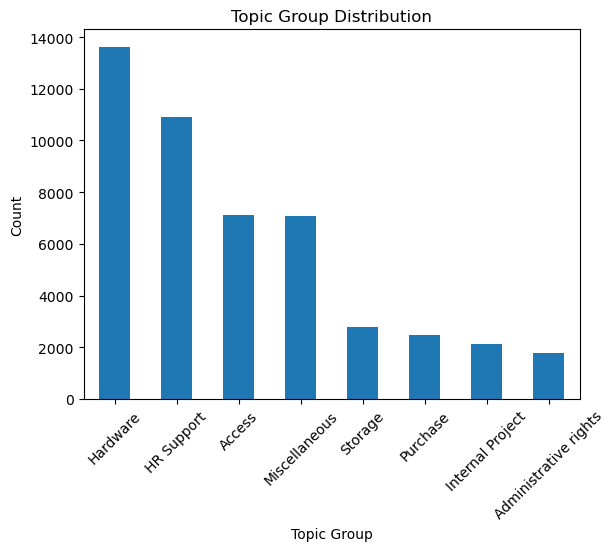

In [5]:
import matplotlib.pyplot as plt

df['Topic_group'].value_counts().plot(kind='bar')

plt.title('Topic Group Distribution')
plt.xlabel('Topic Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Step 4: Text Preprocessing

Machine Learning models cannot directly understand raw text.

Text preprocessing includes:

- Converting text to lowercase
- Removing numbers
- Removing punctuation
- Creating clean text for feature extraction

This helps improve model performance.

In [6]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_text'] = df['Document'].apply(clean_text)

# Step 5: Feature Engineering using TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical features.

Purpose:

- Transform textual ticket descriptions into machine-readable vectors
- Capture important words while reducing the impact of common words
- Prepare data for model training

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

# Step 6: Ticket Category Prediction

A Logistic Regression model is trained to predict ticket categories.

Workflow:

1. Split dataset into training and testing sets
2. Train Logistic Regression model
3. Generate predictions
4. Evaluate model performance

Metrics Used:

- Accuracy Score
- Classification Report

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

y_category = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

model_cat = LogisticRegression(max_iter=1000)
model_cat.fit(X_train, y_train)

pred_cat = model_cat.predict(X_test)

print("Category Accuracy:", accuracy_score(y_test, pred_cat))

report_df = pd.DataFrame(
    classification_report(
        y_test,
        pred_cat,
        output_dict=True
    )
).T

report_df = report_df[['precision', 'recall', 'f1-score', 'support']]

report_df = report_df.round({
    'precision': 2,
    'recall': 2,
    'f1-score': 2,
    'support': 0
})

display(report_df)

Category Accuracy: 0.852633779264214


,precision,recall,f1-score,support
Access,0.92,0.86,0.89,1455.0
Administrative rights,0.87,0.67,0.76,342.0
HR Support,0.85,0.84,0.85,2107.0
Hardware,0.80,0.90,0.84,2760.0
Internal Project,0.92,0.79,0.85,451.0
Miscellaneous,0.82,0.83,0.82,1400.0
Purchase,0.98,0.87,0.92,497.0
Storage,0.94,0.84,0.88,556.0
accuracy,0.85,0.85,0.85,1.0
macro avg,0.89,0.83,0.85,9568.0


# Step 7: Category Prediction Evaluation

A confusion matrix is used to visualize classification performance.

Benefits:

- Shows correct predictions
- Identifies misclassified categories
- Helps evaluate model effectiveness

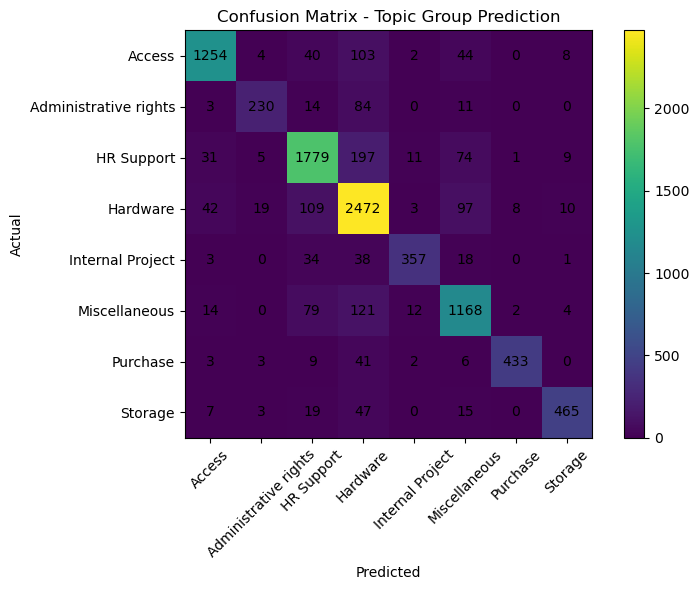

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_cat)

labels = sorted(y_test.unique())

plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.title("Confusion Matrix - Topic Group Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# Step 8: Priority Label Generation

Support tickets often require urgency levels.

Rule-based logic is used to assign:

- High Priority
- Medium Priority
- Low Priority

based on keywords present in ticket descriptions.

In [14]:
def assign_priority(text):
    text = text.lower()

    if any(word in text for word in ["error", "crash", "failed", "urgent", "not working"]):
        return "High"
    elif any(word in text for word in ["issue", "problem", "help", "bug"]):
        return "Medium"
    else:
        return "Low"

df['priority'] = df['Document'].apply(assign_priority)

# Step 9: Ticket Priority Prediction

A second Logistic Regression model is trained to predict ticket priority levels.

Workflow:

- Train model using ticket text features
- Predict ticket priority
- Evaluate prediction performance

Metrics Used:

- Accuracy Score
- Classification Report

In [16]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

y_priority = df['priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

model_pri = LogisticRegression(max_iter=1000)
model_pri.fit(X_train, y_train)

pred_pri = model_pri.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_test, pred_pri))

# Convert report to DataFrame
report_pri_df = pd.DataFrame(
    classification_report(
        y_test,
        pred_pri,
        output_dict=True
    )
).T

# Keep only important metrics
report_pri_df = report_pri_df[
    ['precision', 'recall', 'f1-score', 'support']
]

# Round values
report_pri_df = report_pri_df.round(2)

# Display table
report_pri_df

Priority Accuracy: 0.9587165551839465


,precision,recall,f1-score,support
High,0.99,0.85,0.92,1297.00
Low,0.95,1.00,0.98,5828.00
Medium,0.96,0.92,0.94,2443.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.97,0.92,0.94,9568.00
weighted avg,0.96,0.96,0.96,9568.00


# Step 10: Priority Prediction Evaluation

The confusion matrix visualizes how accurately the model predicts ticket priorities.

It helps identify:

- Correct priority assignments
- Misclassified priorities
- Areas for future improvement

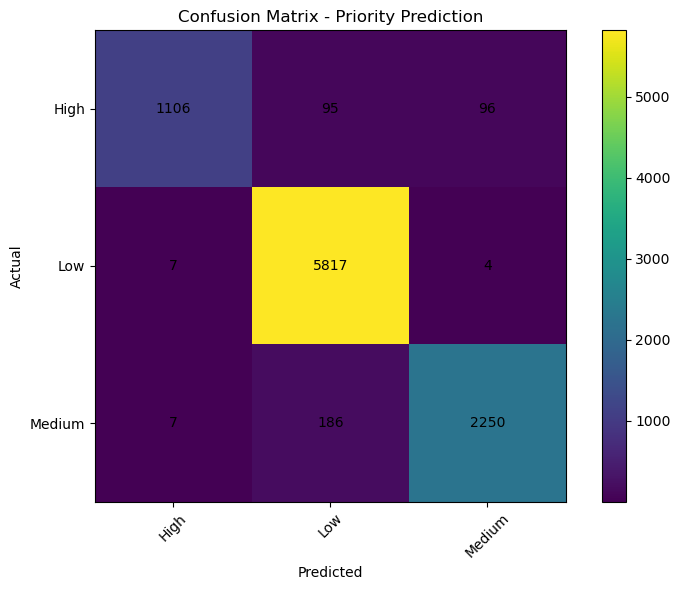

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(y_test, pred_pri)

labels = sorted(y_test.unique())

plt.figure(figsize=(8,6))
plt.imshow(cm2)

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.colorbar()

for i in range(len(cm2)):
    for j in range(len(cm2)):
        plt.text(j, i, cm2[i, j],
                 ha='center',
                 va='center')

plt.title("Confusion Matrix - Priority Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 🎯 Conclusion

In this project, an AI-based Support Ticket Classification System was developed using Machine Learning.

Key Achievements:

✅ Cleaned and preprocessed ticket text data

✅ Converted text into numerical features using TF-IDF

✅ Built a Logistic Regression model for ticket category classification

✅ Generated ticket priorities using rule-based logic

✅ Trained a separate model for priority prediction

✅ Evaluated both models using Accuracy Score, Classification Report, and Confusion Matrix

This project demonstrates how Natural Language Processing (NLP) and Machine Learning can automate support ticket management and improve customer service efficiency.